# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import importlib    
import functions  # First import
importlib.reload(functions)  # Reloads the module to reflect changesx
from functions import *  # Now import functions.py

In [ ]:
df_merged = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/df_merged.pkl')

In [3]:
emission_name = 'CO content in the raw gas (preheater outlet)'

# raw = df_merged[emission_name].values
# noise_filtered = moving_average_n_window(raw, 5)
# df_merged[emission_name] = noise_filtered

d = df_merged.copy() 
d.sort_values(by='no_missing', inplace = True)
len(d)
nox_full = d.drop_duplicates(subset='no_missing', keep='first')
len(nox_full)
col = nox_full.pop('timestamp')
nox_full.insert(1, 'timestamp', col)

e = nox_full.copy()
sequence = e[emission_name].to_list() 
missing_index = []
for i in range(len(e)):
    val = e[emission_name][i]
    if (val <= 27  or val >= 800):        
        missing_index.append(i)   
# missing_index = [i+1 for i in missing_index]        
# sequence = e[ 'CO2 content in the raw gas (preheater outlet)'].to_list() 
# sequence = e['CO content in the raw gas (preheater outlet)'].to_list()
label = 'CO (PPM)' # co2  co nox

dates = e['timestamp'].to_list()   # all dates, no missing date
short_date = [i[0:7] for i in dates]   # taking only year and month
e.insert(0, 'month', short_date, True)   ## adding month to the dataframe. Required for ploting
y = e.drop_duplicates(subset='month', keep='first')
y.reset_index(inplace=True)
index_month = y.loc[:,['index', 'month']]     ##### finding index of 1st month for the dataframe
date_string = [i[:-9] for i in dates]  # Ploted on x axis
index_plot = index_month['index'].to_list()
# month_plot = index_month['month'].to_list()
month_plot = ['2020\nJan','2020\nFeb', '2020\nMar','2020\nApril', '2020\nMay','2020\nJune','2020\nJuly','2020\nAug', '2020\nSept','2020\nOct', '2020\nNov','2020\nDec','2021\nJan','2021\nFeb', '2021\nMar','2021\nApril', '2021\nMay','2021\nJune','2021\nJuly','2021\nAug', '2021\nSept','2021\nOct', '2021\nNov','2021\nDec']

1056960

1056960

In [ ]:
temporal_discont_plot(sequence, label, index_plot, month_plot, missing_index,
                      fig_path = '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/co_discont.pdf')

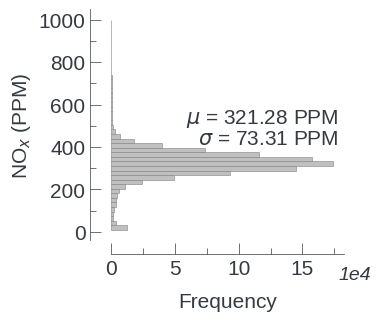

In [ ]:
filtered = [i for i in sequence if (i >=27 and i<= 800)]
mean = np.mean(filtered)
std = np.std(filtered)
s = 15                                 
matplotlib.rcParams['axes.linewidth'] = 0.5
w =0.5

fig, ax = plt.subplots(figsize=(3,3))
_= ax.spines['top'].set_visible(False)
_= ax.spines['right'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 15))
_= ax.spines['bottom'].set_position(('outward', 10))

_= plt.yticks(fontsize=s, fontweight='normal')
vals = [0, 2, 4, 6]
_= plt.xticks([i*10000 for i in vals], vals, rotation = 0, fontsize=s, fontweight='normal')

_= ax.tick_params(which = 'major', width= w, length = 8)
_= ax.tick_params(which = 'minor', width= w, length = 4)
_= ax.tick_params(axis='x', direction ='in', which = 'both')
_= ax.tick_params(axis='y', direction ='in', which = 'both')
_= ax.tick_params(axis='y', which='both', right= False)
_= ax.tick_params(axis='x', which='both', top = False)
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.set_xlabel('Frequency', fontsize = s)

_= ax.hist(filtered, orientation = 'horizontal', color = 'silver',bins= int(1+3.3*np.log(len(filtered))), edgecolor='gray', linewidth= 0.4  )
_= ax.set_xlabel('Frequency', fontsize = s, fontweight= 'normal', labelpad= 10)
_= ax.set_ylabel(label, fontsize = s, fontweight= 'normal')
_= ax.text(
    0.98, 0.5,                      # x=98% (right), y=2% (bottom)
    f'$\mu$ = {mean:.2f} PPM\n$\sigma$ = {std:.2f} PPM', 
    transform=ax.transAxes,           # use axis coordinates
    ha='right',                       # horizontal alignment
    va='bottom',                      # vertical alignment
    linespacing=1,
    fontsize=s,
    fontweight='normal'
)

_=ax.text(
    0.99, -0.17, '1e4',
    transform=ax.transAxes,
    fontsize=s-1,
    style = 'italic',
    bbox=dict(facecolor= 'white', edgecolor='none', pad=1)
)

fig_path =  '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/filtered_hist.pdf'
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000) 
plt.show()

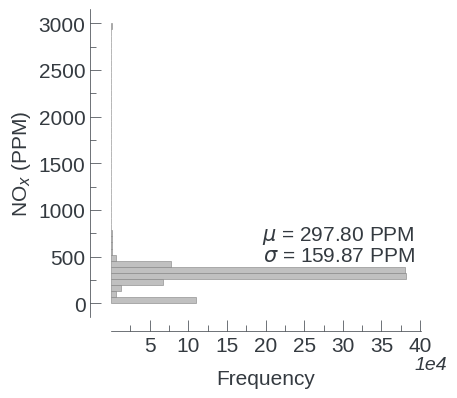

In [ ]:
mean = np.mean(list(np.array(sequence)[~np.isnan(sequence)]))
std = np.std(list(np.array(sequence)[~np.isnan(sequence)]))

s = 15                                 
matplotlib.rcParams['axes.linewidth'] = 0.5
w =0.5

fig, ax = plt.subplots(figsize=(4,4))
_= ax.spines['top'].set_visible(False)
_= ax.spines['right'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 15))
_= ax.spines['bottom'].set_position(('outward', 10))

_= plt.yticks(fontsize=s, fontweight='normal')
vals = [0, 0.2, 0.4, 0.6, 0.8, 1]
_= plt.xticks([i*1000000 for i in vals], vals, rotation = 0, fontsize=s, fontweight='normal')

_= ax.tick_params(which = 'major', width= w, length = 8)
_= ax.tick_params(which = 'minor', width= w, length = 4)
_= ax.tick_params(axis='x', direction ='in', which = 'both')
_= ax.tick_params(axis='y', direction ='in', which = 'both')
_= ax.tick_params(axis='y', which='both', right= False)
_= ax.tick_params(axis='x', which='both', top = False)
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.set_xlabel('Frequency', fontsize = s)
_= ax.set_ylabel(label, fontsize = s, fontweight= 'normal')

_= ax.hist(sequence, orientation = 'horizontal', color = 'silver',bins= int(1+3.3*np.log(len(sequence))), edgecolor='gray', linewidth= 0.4  )
_= ax.set_xlabel('Frequency', fontsize = s, fontweight= 'normal', labelpad= 10)
_= ax.text(
    0.98, 0.1,                      # x=98% (right), y=2% (bottom)
    f'$\mu$ = {mean:.2f} PPM\n$\sigma$ = {std:.2f} PPM', 
    transform=ax.transAxes,           # use axis coordinates
    ha='right',                       # horizontal alignment
    va='bottom',                      # vertical alignment
    linespacing=1,
    fontsize=s,
    fontweight='normal'
)

_=ax.text(
    0.96, -0.16, '1e6',
    transform=ax.transAxes,
    fontsize=s-1,
    style = 'italic',
    bbox=dict(facecolor='white', edgecolor='none', pad=1)
)

fig_path =  '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/raw_hist.pdf'
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000) 
plt.show()

# Analysis

In [3]:
emission_name = 'CO content in the raw gas (preheater outlet)'
raw = df_merged[emission_name].values
noise_filtered = moving_average_n_window(raw, 5)
df_merged[emission_name] = noise_filtered

minutely = df_merged[['timestamp', 'no_missing', emission_name]]
minutely.reset_index(inplace=True)

look_back_steps = 25
look_back_period = look_back_steps + 1 #20 minutes

missing_index = []     # indicies of df_merge at which outlier occur.
for i in range(len(minutely)):
    val = minutely[emission_name][i]
    if (val <= 27  or val >= 800):        ##### ***** change here if you want to exclude zeros !
        missing_index.append(i)      # append the required index of the hourly df.
print(f'{len(missing_index)} outside range out of {len(minutely)} minutes datapoits')
count = 0    # cont of windows available for model development
window = []   # filtered window indicies for minutely
len_of_window = []
non_zero_windows = []   # filtered non-zero window indicies for minuterly
for i in range(len(missing_index)):
    if count ==0:
        window.append((0,missing_index[i]))
        count += 1
    else:
        window.append((missing_index[i-1]+1,missing_index[i]))
        count += 1
        if i == len(missing_index) - 1:
            window.append((missing_index[i]+1,len(minutely)))
window_start = []
window_end = []
for i in window:
    a,b = i
    length = b-a
    if length >= look_back_period+1:
        non_zero_windows.append(i)
        len_of_window.append(length)
        window_start.append(a)
        window_end.append(b)
# len_win_hrs = [i/4 for i in len_of_window ] 
working_windows = pd.DataFrame({'start':window_start, 'index range': non_zero_windows,'end':window_end,  'win length':len_of_window})
working_windows.reset_index(inplace=True)
working_windows.rename(columns={'index':'window number'}, inplace=True)

train_val = working_windows[working_windows['end']<=881280] #upto Aug 2021

buffer = working_windows[(working_windows['start']>=881280 )& (working_windows['end']<=969120)] #Sept-Oct 2021

test = working_windows[working_windows['start']>=969120]#Nov-Dec 2021
Time = []
for i in test['index range'].values:
    a = i[0]
    b = i[1]
    Time.append((list(minutely[minutely['no_missing'] == a]['timestamp'])[0], list(minutely[minutely['no_missing'] == b-1]['timestamp'])[0]))
test['time_range'] = Time

t_v = train_val['win length'].sum()
b = buffer['win length'].sum()
t = test['win length'].sum()
total_window_pts = working_windows['win length'].sum()  # toal data-points (minutes) in working window
(t_v/total_window_pts)*100
(b/total_window_pts)*100
(t/total_window_pts)*100

m1 = train_val['window number'].min()
M1 =train_val['window number'].max()

m2 = buffer['window number'].min()
M2 =buffer['window number'].max()

m3 = test['window number'].min()
M3 =test['window number'].max()

print(f'train_val df window numbers: min= {m1} & max = {M1}')
print(f'buffer df window numbers: min= {m2} & max = {M2}')
print(f'test df window numbers: min= {m3} & max = {M3}')

df_names = []
for i in range(look_back_period-1):
    df_names.append(i+1)
df_names.append('y')
df_names = ['window number'] + df_names
df_backbone = pd.DataFrame(columns = df_names)

all_rows = []
all_index_no_missing = []
window_number = 0
for start, finish in tqdm(non_zero_windows):
    piece_meal = minutely[start:finish][emission_name].to_list()
    piece_meal_no_missing = minutely[start:finish]['no_missing'].to_list()
    for i in range(len(piece_meal) - look_back_steps):  #2
        values = piece_meal[i:i + look_back_period]
        all_index_no_missing.append(piece_meal_no_missing[i + look_back_period-1])
        all_rows.append([window_number] + values)
    window_number +=1

# After collecting everything, create DataFrame once
df_backbone = pd.DataFrame(all_rows)
df_backbone.columns = df_names
df_backbone['no_missing'] = all_index_no_missing
df_backbone = df_backbone.merge(df_merged[['no_missing','timestamp' ]], on = 'no_missing', how = 'left')
df_backbone.dropna(axis = 0, how = 'any', inplace = True)

Ts_train = df_backbone[df_backbone['window number']<=M1]
Ts_buffer = df_backbone[(df_backbone['window number']>=m2) & (df_backbone['window number']<=M2)]
Ts_test = df_backbone[df_backbone['window number']>=m3]

X_train = Ts_train.iloc[:, 1:-3]
y_train = Ts_train.iloc[:,[-3]]

X_test= Ts_test.iloc[:, 1:-3]
y_test= Ts_test.iloc[:,[-3]]

y = pd.concat([y_train,y_test])

np.random.seed(1002)
random.seed(0)
# Separate scalers for X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scale inputs (X)
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# Scale outputs (y)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten() # Convert y_df to NP arrays before reshaping
y_test_s = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

108953 outside range out of 1056960 minutes datapoits



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


82.79091366842547

7.856075960614895

8.599835824874225

train_val df window numbers: min= 0 & max = 629
buffer df window numbers: min= 630 & max = 677
test df window numbers: min= 679 & max = 758


100%|██████████| 759/759 [00:02<00:00, 343.94it/s]


<div style="color: red; font-size: 28px">  
Dont run this code again from this point to ...
</div>

# Training 30 models (single step)

In [ ]:
# seeds = 30
# np.random.seed(1002)
# random.seed(0)

# December_names = []
# for i in range(len(X_train)):
#     December_names.append(i+1)
# December_backbone_train = pd.DataFrame(December_names)

# December_names = []
# for i in range(len(X_test)):
#     December_names.append(i+1)
# December_backbone = pd.DataFrame(December_names)

# for inter in range(0,seeds):  # 10 models
    
#     model = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),  # deeper + more capacity
#     max_iter=100,                      # allow more training epochs
#     batch_size=512,                    # increase batch size to speed up + stabilize
#     learning_rate_init=0.001,         # keep as-is (try 0.0005 if overfitting)
#     solver='adam',                    # good for large datasets
#     random_state= inter,
#     verbose=True,
#     early_stopping=True,             
#     validation_fraction=0.1,
#     n_iter_no_change=10    
#     )
#     model.fit(X_train_s,y_train_s)
#     with open(f'/home/m3rg2000/Junaid_temporary/saved_models/forecast/co/model_{inter}.pkl', 'wb') as f:   # model 0 to 29. 
#         pickle.dump(model,f)
#     # model = pickle.load(open(f'/home/m3rg2000/Junaid_temporary/saved_models/forecast/co/model_{inter}.pkl', 'rb'))
    
#     test_pred_s = model.predict(X_test_s).reshape(-1,1)
#     train_pred_s = model.predict(X_train_s).reshape(-1,1)
#     test_pred = scaler_y.inverse_transform(test_pred_s)
#     train_pred = scaler_y.inverse_transform(train_pred_s)
    
#     Dec_pred_per_model = pd.DataFrame(test_pred)
#     Dec_pred_per_model_train = pd.DataFrame(train_pred)
    
#     December_backbone = pd.concat([December_backbone,Dec_pred_per_model], axis =1)   
#     December_backbone_train = pd.concat([December_backbone_train,Dec_pred_per_model_train], axis =1)   

### Compile model results into df

In [ ]:
# December_backbone_train.columns = range(December_backbone_train.shape[1])
# December_backbone.columns = range(December_backbone.shape[1])

# December_backbone.drop(December_backbone.columns[0], axis=1, inplace= True)
# December_backbone_train.drop(December_backbone_train.columns[0], axis=1, inplace= True)

# mean_values = December_backbone.mean(axis=1)
# std_values = December_backbone.std(axis=1)
# December_backbone.insert(0, 'mean', mean_values)
# December_backbone.insert(1, 'std', std_values)

# mean_values = December_backbone_train.mean(axis=1)
# std_values = December_backbone_train.std(axis=1)
# December_backbone_train.insert(0, 'mean', mean_values)
# December_backbone_train.insert(1, 'std', std_values)

# actual = y_test.reset_index() # index here is the index of df_backbone
# y_test_actual = actual.merge(df_backbone.reset_index()[['index','no_missing','timestamp']], on = 'index', how = 'left')
# December_backbone = pd.concat([December_backbone,y_test_actual.iloc[:,-2:]], axis = 1)

### Avg results (mean, std) of the seed training

In [ ]:
# mean_tets_pred = December_backbone_train['mean'].to_list()
# mean_train_pred = December_backbone['mean'].to_list()

# std_tets_pred = December_backbone_train['std'].to_list()
# std_train_pred = December_backbone['std'].to_list()

# December_backbone_train['actual'] = y_train.values
# December_backbone['actual'] = y_test.values
# December_backbone.insert(0, 'stdx3',list(December_backbone['std']*3))

# train_error_metrics = pd.DataFrame(index=['R2', 'MAE', 'MAPE'])
# for i in range(seeds):
#     train_error_metrics[i+1] = get_score_custom(December_backbone_train['actual'],December_backbone_train[i+1]) 
    
# mean_values = train_error_metrics.mean(axis=1)
# std_values = train_error_metrics.std(axis=1)
# train_error_metrics.insert(0, 'mean', mean_values)
# train_error_metrics.insert(1, 'std', std_values)


# test_error_metrics = pd.DataFrame(index=['R2', 'MAE', 'MAPE'])
# for i in range(seeds):
#     test_error_metrics[i+1] = get_score_custom(December_backbone['actual'],December_backbone[i+1]) 
    
# mean_values = test_error_metrics.mean(axis=1)
# std_values = test_error_metrics.std(axis=1)
# test_error_metrics.insert(0, 'mean', mean_values)
# test_error_metrics.insert(1, 'std', std_values)

Save the 30 seed training model predicitons and statistics

In [ ]:
# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/train_seeds_nox.pkl', 'wb') as f:  
#     pickle.dump(December_backbone_train,f)
    
# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/test_seeds_co.pkl', 'wb') as f: 
#     pickle.dump(December_backbone,f)
    
# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/avg_train_metrics.pkl', 'wb') as f:  
#     pickle.dump(train_error_metrics,f)

# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/avg_test_metrics.pkl', 'wb') as f:  
#     pickle.dump(test_error_metrics,f)

<div style="color: red; font-size: 28px">  
Dont run any of the code again above this point ...
</div>


# Directly read the code executed above

Visulalize model prediction for Nov and Dec 2021

In [4]:
prediction_horizon = 60
December_backbone = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/test_seeds_co.pkl', 'rb'))
December_backbone_train = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/train_seeds_co.pkl', 'rb'))

<div style="color: red; font-size: 28px">  
Single step forecaster below
</div>


# parity plot for mean Single step forecaster prediction

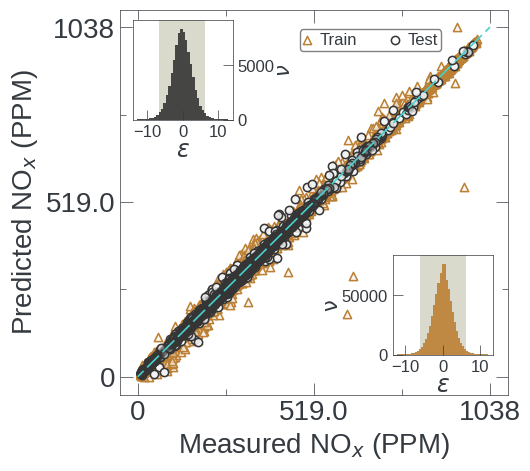

In [ ]:
test_actual = December_backbone['actual'].to_list()
test_pred= December_backbone['mean'].to_list()
test_std = December_backbone['stdx3'].to_list()

train_actual = December_backbone_train['actual'].to_list()
train_pred= December_backbone_train['mean'].to_list()
train_std = December_backbone_train['std'].to_list()

y = pd.concat([y_train,y_test])
y = array_to_list(y.values)

fig_path = '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/single_step_forecast_parity.pdf'
label = 'CO (PPM)'
parity_train_test_no_model_s_font(label, train_actual, test_actual, train_pred,test_pred, y, fig_path= fig_path)

In [ ]:
e= December_backbone.copy()
dates = e['timestamp'].to_list()   # all dates, no missing date
short_date = [i[0:7] for i in dates]   # taking only year and month
e.insert(0, 'month', short_date, True)   ## adding month to the dataframe. Required for ploting
y = e.drop_duplicates(subset='month', keep='first')
y.reset_index(inplace=True)
index_month = y.loc[:,['index', 'month']]     ##### finding index of 1st month for the dataframe
index_plot = index_month['index'].to_list()
month_plot = index_month['month'].to_list()

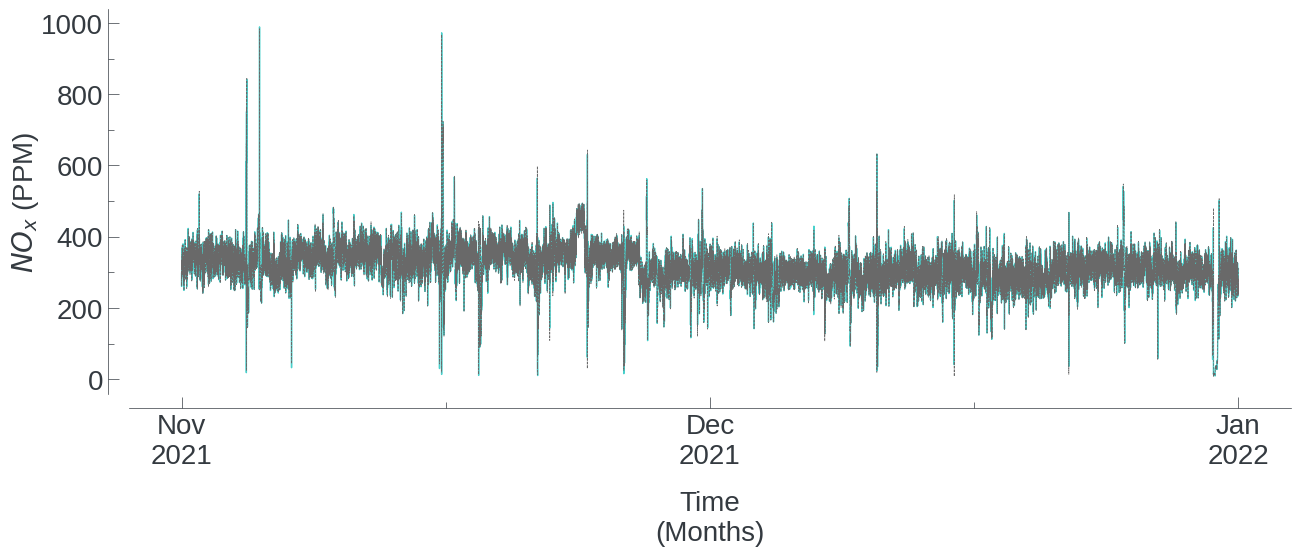

In [ ]:
label = 'CO (PPM)'
values_mean = December_backbone['mean'].to_list() 
values_std = December_backbone['stdx3'].to_list()
# values_std = December_backbone['std'].to_list()
values_actual= December_backbone['actual'].to_list()

s = 20
w =0.5                                
matplotlib.rcParams['axes.linewidth'] = 0.5

start= 0
end = len(values_actual)
y_a =             values_actual[start:end]
y_m=              values_mean[start:end]
y_std=              values_std[start:end]
y_3sigma_min = [x - y for x, y in zip(y_m, y_std)]
y_3sigma_max = [x + y for x, y in zip(y_m, y_std)]

figure, ax = plt.subplots(figsize=(15,5))  #dimgray

_= ax.spines['top'].set_visible(False)
_= ax.spines['right'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 15))
_= ax.spines['bottom'].set_position(('outward', 10))
_= plt.yticks(fontsize=s, fontweight='normal')

_= ax.set_xticks([0, len(y_a)/2, len(y_a)], labels = ['Nov\n2021','Dec\n2021','Jan\n2022', ] , rotation = 0, fontsize= s, fontweight= 'normal') 

_= ax.tick_params(which = 'major', width= w, length = 8)
_= ax.tick_params(which = 'minor', width= w, length = 4)
_= ax.tick_params(axis='x', direction ='in', which = 'both')
_= ax.tick_params(axis='y', direction ='in', which = 'both')
_= ax.tick_params(axis='y', which='both', right= False)
_= ax.tick_params(axis='x', which='both', top = False)
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.set_xlabel('Time\n(Months)', fontsize = s, labelpad = 15)
_= ax.set_ylabel(label, fontsize = s, labelpad = 0)


_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
  #, alpha = 1, edgecolors='black', linewidth =1
# ax.plot([i+1 for i in range(len(values_std))],values_std,color = 'black', linewidth =0.3)  
_= ax.plot([i+1 for i in range(len(y_a))],y_a,color = 'mediumturquoise', linewidth =1, label = '$Plant data$')  
_= ax.plot([i+1 for i in range(len(y_m))],y_m,color = 'dimgray', linewidth =0.5, ls = '--', label = '$NOx mean$') 
fig_path =  '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/ts_zoomout.pdf'
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000) 
plt.show()

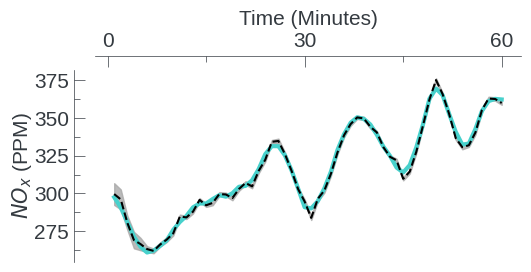

In [ ]:
label = 'CO (PPM)'
s = 15
w =0.5                                
matplotlib.rcParams['axes.linewidth'] = 0.5

# start= 3 * int(len(values_actual)/4) #-60
start = 0
# start= int(len(values_actual)-60)
end = int(start+ 60)
y_a =             values_actual[start:end]
y_m=              values_mean[start:end]
y_std=              values_std[start:end]
y_3sigma_min = [x - y for x, y in zip(y_m, y_std)]
y_3sigma_max = [x + y for x, y in zip(y_m, y_std)]

figure, ax = plt.subplots(figsize=(5.5,2.5))  #dimgray

_= ax.spines['bottom'].set_visible(False)
_= ax.spines['right'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 15))
_= ax.spines['top'].set_position(('outward', 10))
_= plt.yticks(fontsize=s, fontweight='normal')

_= ax.set_xticks([0, len(y_a)/2, len(y_a)], labels = [0,30, 60 ] , rotation = 0, fontsize= s, fontweight= 'normal') 

_= ax.tick_params(which = 'major', width= w, length = 8)
_= ax.tick_params(which = 'minor', width= w, length = 4)
_= ax.tick_params(axis='x', direction ='in', which = 'both')
_= ax.tick_params(axis='y', direction ='in', which = 'both')
_= ax.tick_params(axis='y', which='both', right= False)
_= ax.tick_params(axis='x', which='both', top = True)
_= ax.tick_params(axis='x', which='both', bottom = False)
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.set_xlabel('Time (Minutes)', fontsize = s, labelpad = 5)
_= ax.set_ylabel(label, fontsize = s, labelpad = 0)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')


_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
  #, alpha = 1, edgecolors='black', linewidth =1
# ax.plot([i+1 for i in range(len(values_std))],values_std,color = 'black', linewidth =0.3)  
_= ax.plot([i+1 for i in range(len(y_a))],y_a,color = 'mediumturquoise', linewidth =3, label = '$Plant data$')  
_= ax.plot([i+1 for i in range(len(y_m))],y_m,color = 'black', linewidth =1.5, ls = '--', label = '$NOx mean$') 
_= plt.fill_between([i+1 for i in range(len(y_a))], y_3sigma_min,y_3sigma_max, color = 'darkgray', alpha = 0.8, label = '$\pm$'+' '+ '3'+'$\sigma$')
fig_path =  '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/ts_zoomin.pdf'
_= plt.savefig(fig_path, bbox_inches='tight', transparent = False, dpi = 1000) 
plt.show()

<div style="color: red; font-size: 28px">  
Multi step vs Single step forecaster:
</div>

### Load 60 min of multi step forecaster details below

In [5]:
pred_60_actual = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/60_multi_op/y_test.pkl', 'rb'))
pred_60_std = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/60_multi_op/y_test_std_pred.pkl', 'rb'))
pred_60_mean = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/60_multi_op/y_test_mean_pred.pkl', 'rb'))
random_trials_df= pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/random_trials.pkl', 'rb'))
abs_errors= pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/random_trials_ab_error.pkl', 'rb'))
ape_std_tf = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/60_multi_op/ape_std_df.pkl', 'rb'))

std_pred_tf = pred_60_std.iloc[:,3:]
std_pred_tf.columns = list(range(60))

# Protocol for error calculations

In [14]:
# error_type = 'percentage_error'
error_type = 'absolute_percentage_error'

error_method = 'type_1' #  mean error = mean_prediciton - actual
# error_method = 'type_2' #  mean error = mean(errors)  # in both methods, std is same: std of errors. # mean and std occurs due to seed trainings in single and multistep forecasters

error_df_multi_step, error_std_multi_step = error_calculations_protocal(error_type, error_method)

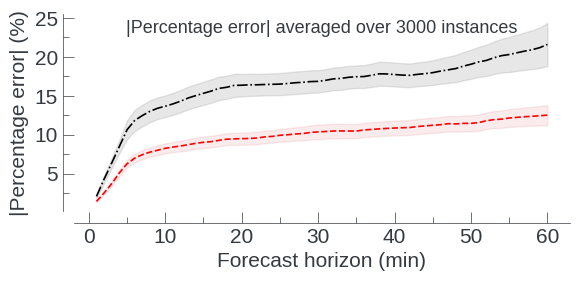

In [15]:
fig_path = '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/avg_errors_compare.pdf'
avg_errors_compare(fig_path = fig_path) # error_method = type_1 mean error = mean pred minus acutal

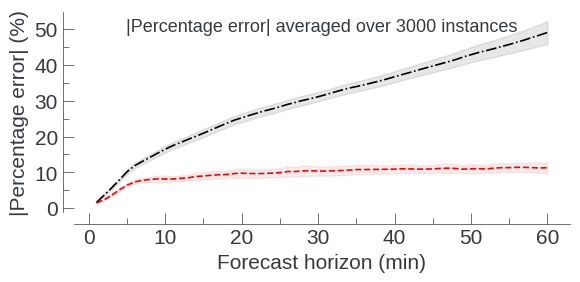

In [49]:
avg_errors_compare(fig_path = None) # error_method = type_2 mean error = mean(errors)

# Select y_1 index of Multi step and check for single step

Index is the index of error_df_multi_step (same as index of pred_60_mean, i.e., index of test set for 60 OP predictions)   

y_1 is just the row number (serial) of the pred_60_mean

Case: Error metric multi step (all test points) [Use thsi case for getting the later plots]

# Mapping formation

In [18]:
# Error metric TF (all test points)
predicted_df = pred_60_mean.iloc[:, 3:].copy()
actual_df = pred_60_actual.copy()
actual_df.columns = list(range(1,61))
actual_df.reset_index(inplace=True)
actual_df.drop(columns = ['index'], inplace = True)
percentage_error_df = (abs(predicted_df - actual_df) / actual_df) * 100
error_df_multi_step = abs(percentage_error_df)

sum_Pe = error_df_multi_step.iloc[:,:20].sum(axis=1)
error_df_multi_step.reset_index(inplace = True)
error_df_multi_step['sum_Pe_20_min'] = sum_Pe
mapping = error_df_multi_step[['index', 'sum_Pe_20_min']]
mapping.rename(columns={'index':'test_serial'}, inplace = True)
mapping.sort_values(by='sum_Pe_20_min', ascending=True, inplace = True)
error_df_multi_step.drop(columns = ['index', 'sum_Pe_20_min'], inplace = True)


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Multi step forecaster error

In [ ]:
variability = predicted_df.iloc[:, 10:20].diff(axis=1).iloc[:, 1:].abs().mean(axis=1).values
var_df = pd.DataFrame({'serial_y_test': list(range(len(pred_60_actual))),'variability': variability})# index
var_df.sort_values(by='variability', ascending=False, inplace = True)
serials = var_df.iloc[0:100,:]['serial_y_test'].values  

# Forecast for a single serial

In [22]:
error_type = 'percentage_error'
# error_type = 'absolute_percentage_error'

error_method = 'type_1' #  mean error = mean_prediciton - actual
# error_method = 'type_2' #  mean error = mean(errors)  # in both methods, std is same: std of errors. # mean and std occurs due to seed trainings in single and multistep forecasters

error_df_multi_step, error_std_multi_step = error_calculations_protocal(error_type, error_method)

72490


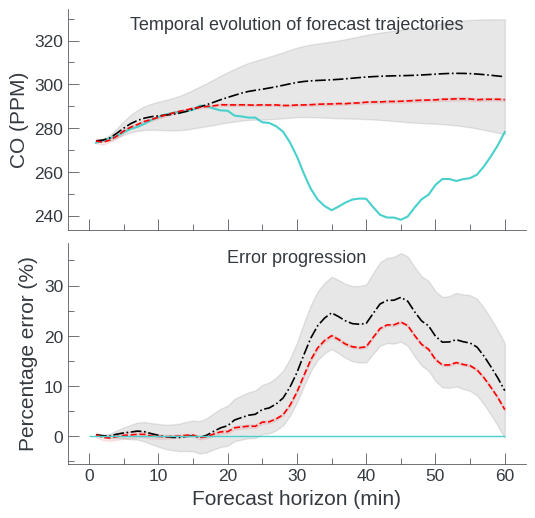

In [44]:
np.random.seed(1002)
random.seed(0)
seeds = 30 # number of single step models
serial = 72490
std_factor = 1.645 # 1.28 =  80%, 1.645 = 90%, 1.96 = 95%,  3.8906 = 99.99%

TF_pred_mean, TF_pred_std, error_std_multi_step_, test_actual, testing_patch, testing_patch_df = path_create(serial) # all these are notebook functions
prediction_names, prediction_backbone = single_step_moving_window_create(serial)
step_error_metric = single_step_stats(serial, prediction_names, prediction_backbone)
mean_plus_3std,mean_minus_3std,mean_plus_3std_tf, mean_minus_3std_tf,median_plus_3std, median_minus_3std, median_minus_3std_tf , median_plus_3std_tf, testing_list, mean, median_frc_scores = mean_std_calculate(
    serial, std_factor, testing_patch_df, December_backbone, prediction_backbone, TF_pred_mean, TF_pred_std, step_error_metric, error_std_multi_step_) 
plot_final_fig(serial, testing_list, mean, median_frc_scores,TF_pred_mean,mean_plus_3std, mean_minus_3std, 
               mean_minus_3std_tf, mean_plus_3std_tf, median_plus_3std, median_minus_3std_tf, median_plus_3std_tf)

# Forecast for select serials

PE, type 1

1
60433


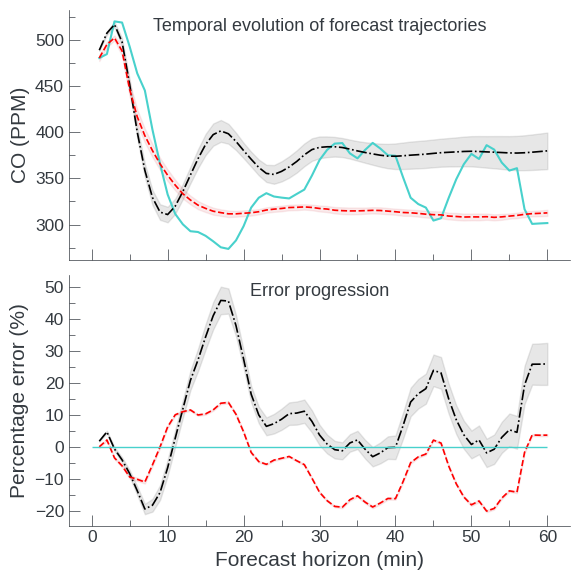

2
56085


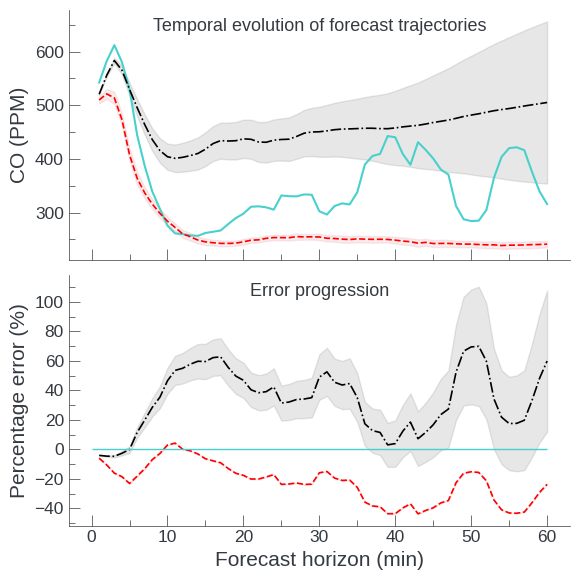

3
56086


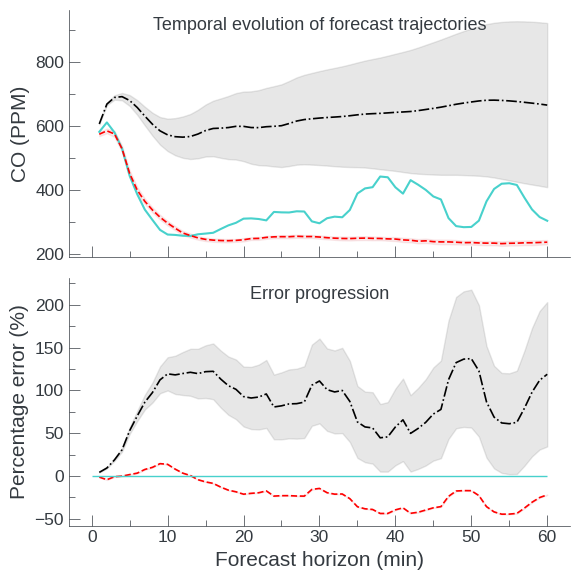

4
57371


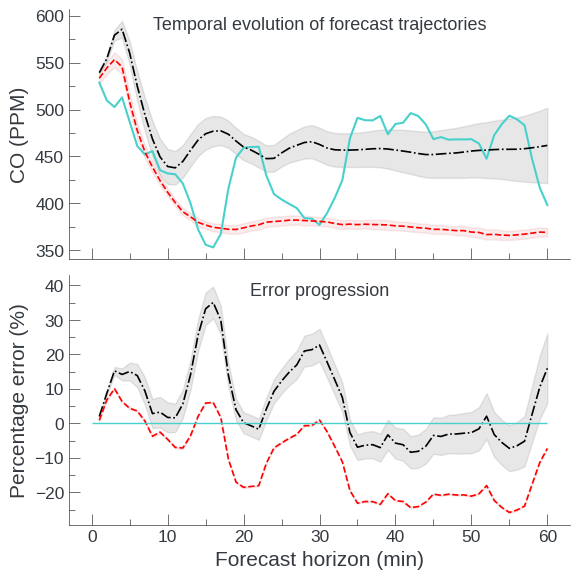

5
29856


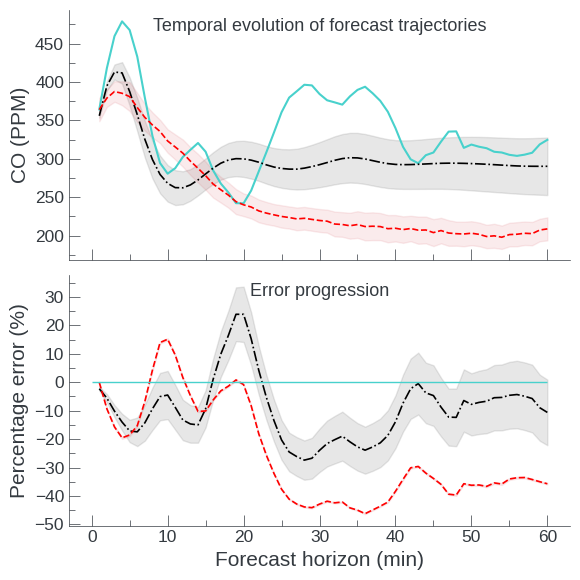

6
50337


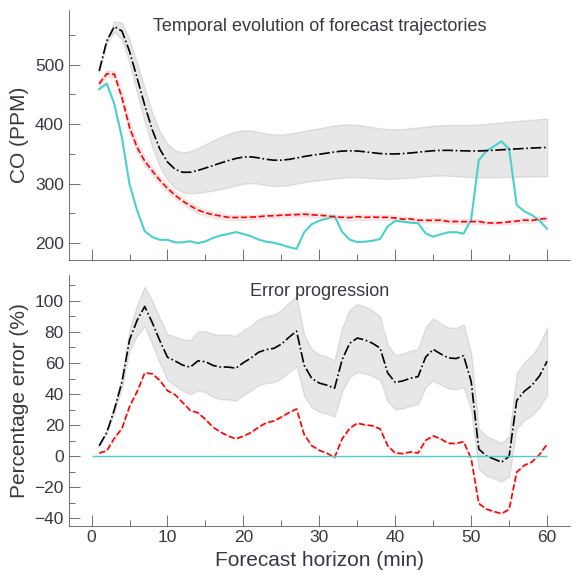

7
67107


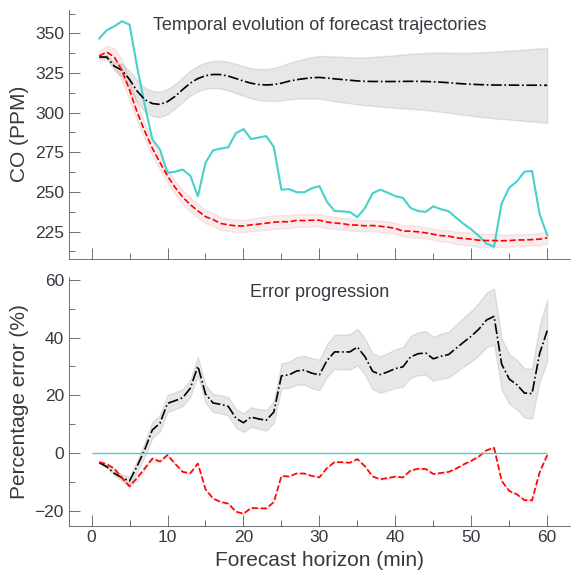

8
29859


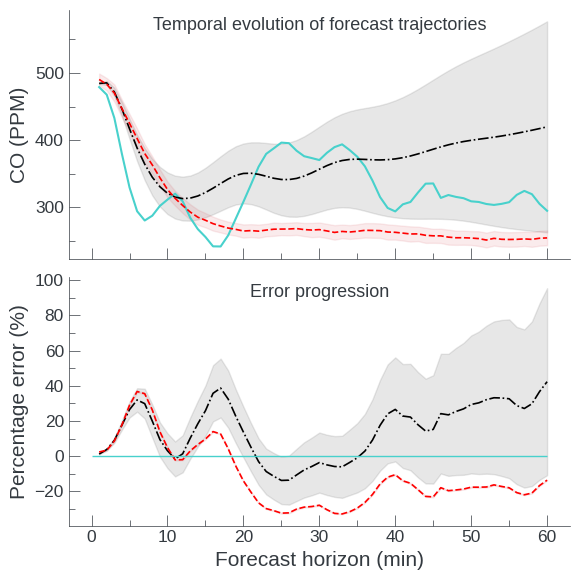

9
65445


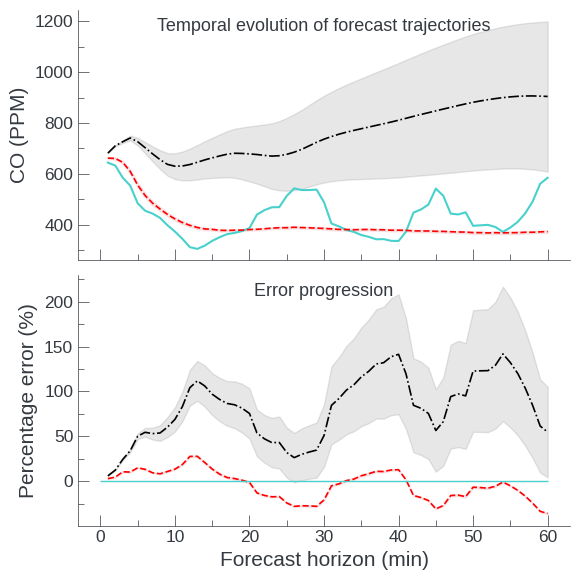

10
29884


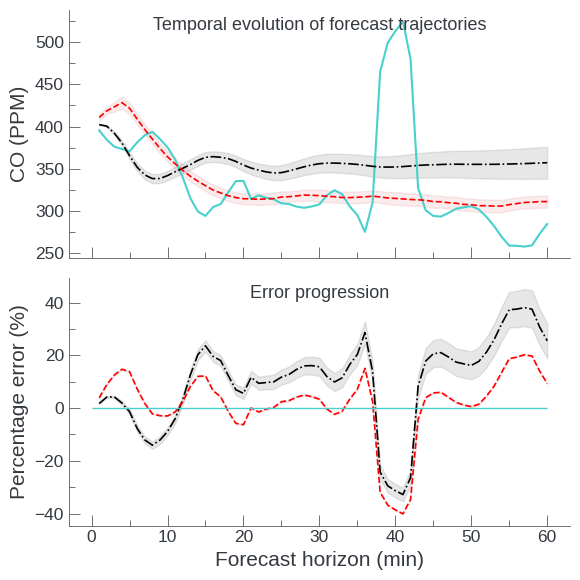

11
1736


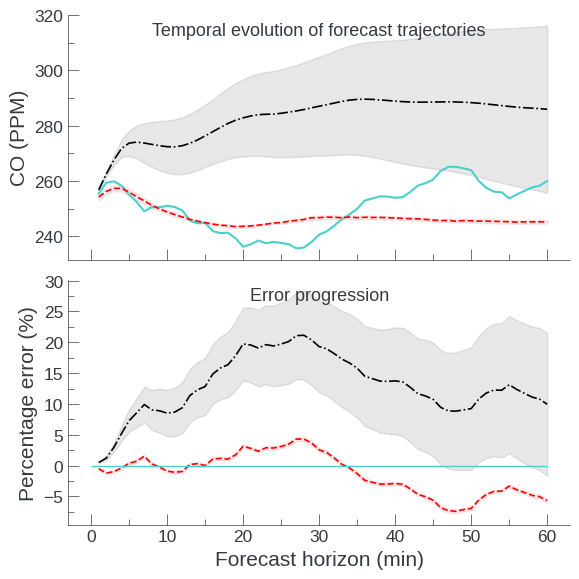

12
61152


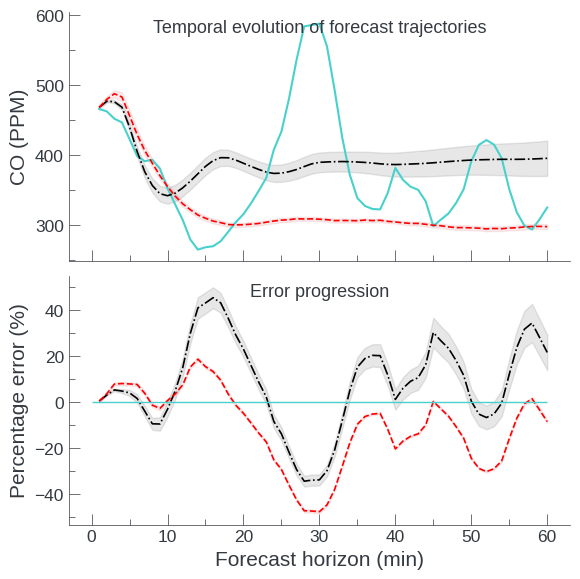

13
61153


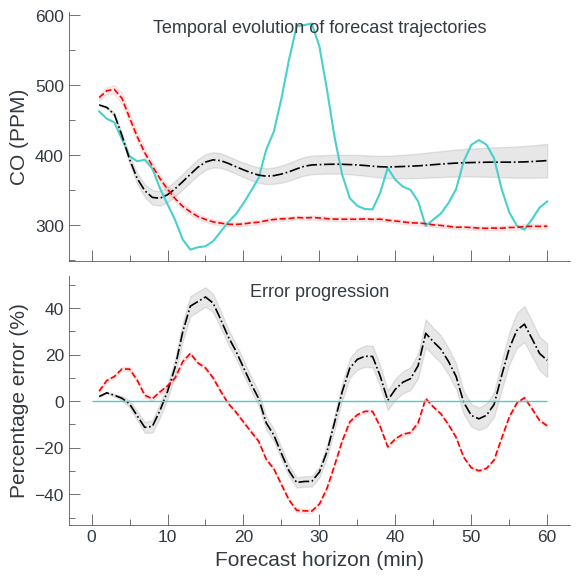

14
67556


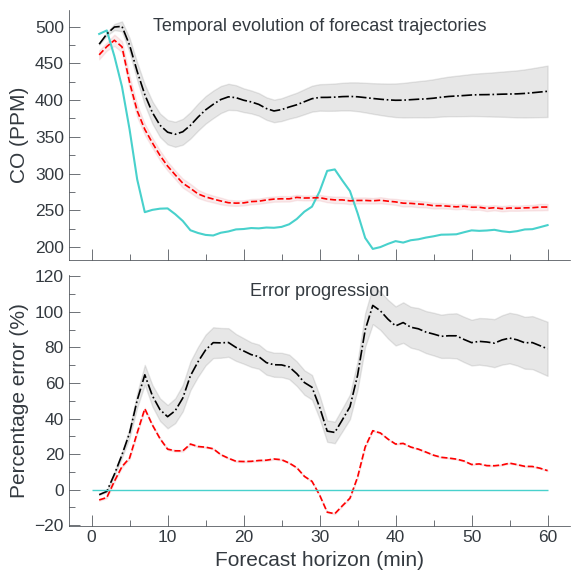

15
63083


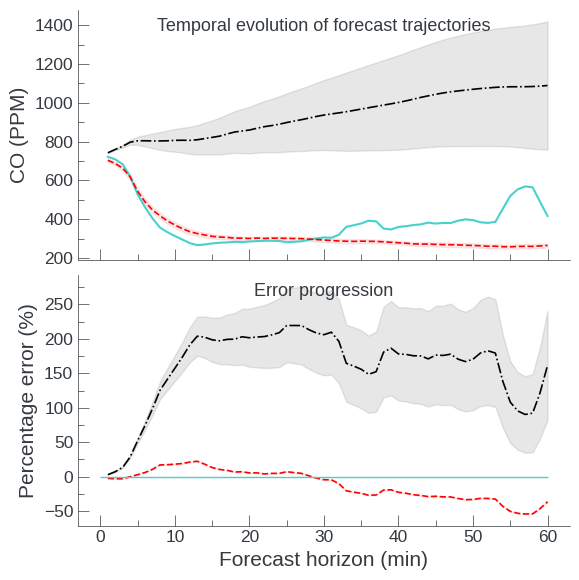

16
63084


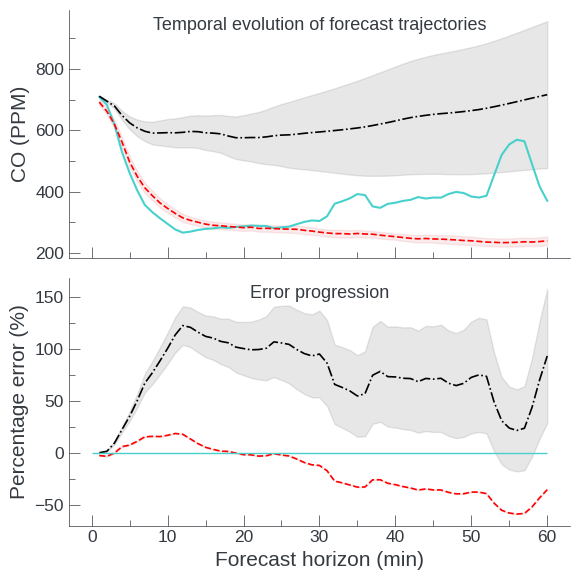

17
64877


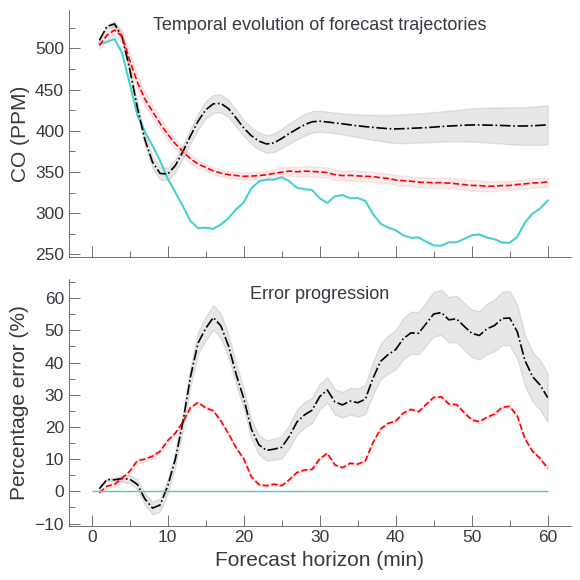

18
64878


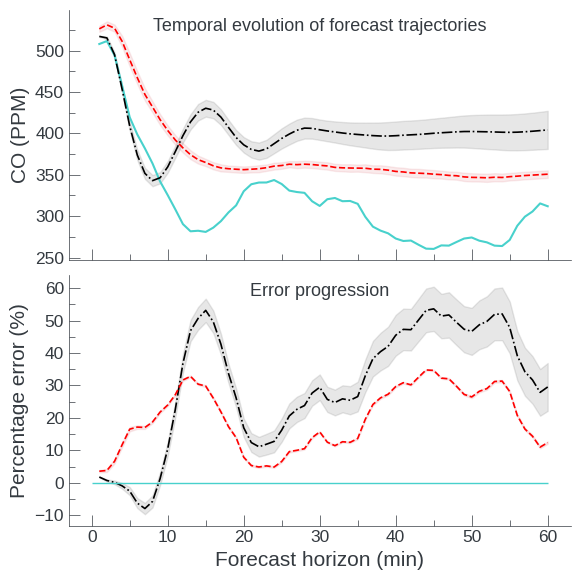

19
66547


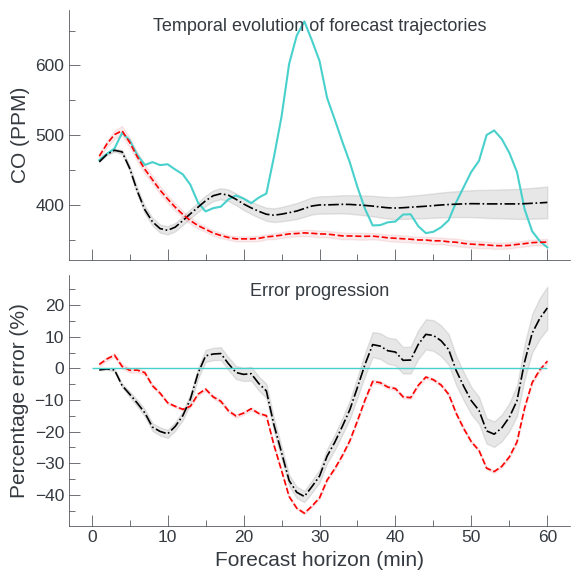

20
66548


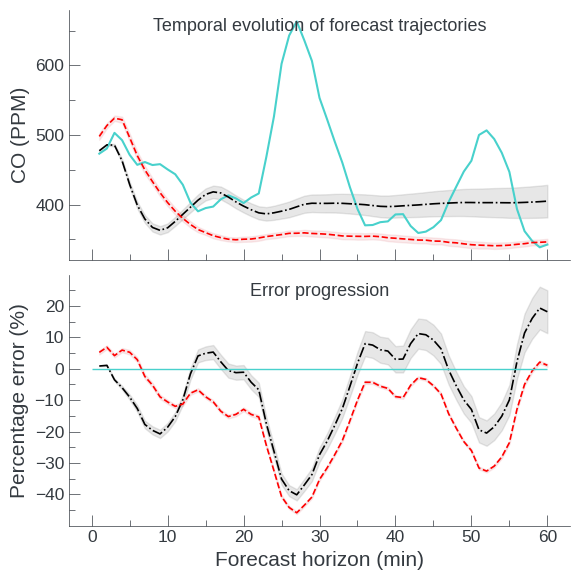

In [ ]:
np.random.seed(1002)
random.seed(0)
seeds = 30 # number of single step models
std_factor = 1.645 # 1.28 =  80%, 1.645 = 90%, 1.96 = 95%,  3.8906 = 99.99%
n = 0
base_path = '/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/forecast/co/trajectories/'

for serial in serials:
    n+= 1
    print(n)
    TF_pred_mean, TF_pred_std, error_std_multi_step_, test_actual, testing_patch, testing_patch_df = path_create(serial) # all these are notebook functions
    prediction_names, prediction_backbone = single_step_moving_window_create(serial)
    step_error_metric = single_step_stats(serial, prediction_names, prediction_backbone)
    mean_plus_3std,mean_minus_3std,mean_plus_3std_tf, mean_minus_3std_tf,median_plus_3std, median_minus_3std, median_minus_3std_tf , median_plus_3std_tf, testing_list, mean, median_frc_scores = mean_std_calculate(
        serial, std_factor, testing_patch_df, December_backbone, prediction_backbone, TF_pred_mean, TF_pred_std, step_error_metric, error_std_multi_step_) 
    plot_final_fig(serial, testing_list, mean, median_frc_scores,TF_pred_mean,mean_plus_3std, mean_minus_3std, 
               mean_minus_3std_tf, mean_plus_3std_tf, median_plus_3std, median_minus_3std_tf, median_plus_3std_tf, 
               fig_path = base_path+f'{n}.pdf')

# Supplementary code

<div style="color: red; font-size: 28px">  
Random single step forecaster sampling points [Dont run again]
</div>


### Error_method = type_1

Computing abs_error dataframe (mean error df is computed, then we calulate abs % errors).  
Here we dont avg errors, we avg mean preds, then calculate avg PE at last

In [ ]:
# run time = 13 minute for 
window_tested = []
window_index_tested = []
random_forecast_per_window = 50
random_trials= []
mean_predictions_all = []  # list to hold mean predictions for all trials
actual_values_all = []     # list to hold actual values for all trials
model_path ='/home/m3rg2000/Junaid_temporary/saved_models/forecast/co2/model_'
for testing_window_serial in tqdm(range(len(test))):
    if test.iloc[testing_window_serial,:]['win length'] >= look_back_steps+prediction_horizon+random_forecast_per_window:
        win = test.iloc[testing_window_serial,:]['window number']
        window_tested.append(win)
        window = test['index range'].values[testing_window_serial]
        testing_patch_df = minutely[(minutely['no_missing']>= window[0]) & (minutely['no_missing']< window[1])]
        testing_patch_ = testing_patch_df[emission_name].values
        max_sample_index = len(testing_patch_) - (prediction_horizon+look_back_steps)
        for i in range(random_forecast_per_window):
            begin_index = random.randint(0, max_sample_index)
            window_index_tested.append((win, begin_index))
            test_actual = testing_patch_[begin_index+look_back_steps:begin_index+look_back_steps+prediction_horizon]
            testing_patch = scaler_y.transform(testing_patch_.reshape(-1, 1)).flatten()  # scalled values
            # np.random.seed(1002)
            # random.seed(0)
            prediction_names = []  
            for i in range(prediction_horizon):
                prediction_names.append(i+1)
            prediction_backbone = pd.DataFrame(columns = prediction_names )

            for model_serial in range(seeds):
                model = pickle.load(open(model_path+ f'{model_serial}' + '.pkl', 'rb'))
                model_predictions = np.array([]).reshape(1, -1)
                count = 0
                test_initialize = testing_patch[begin_index:begin_index+look_back_steps].copy()  # very importtant to reset it here.*******
                test_initialize = test_initialize.reshape(1, -1)
                while count < prediction_horizon:
                    y = model.predict(test_initialize)[0]
                    test_initialize = np.append(test_initialize[:, 1:], [[y]], axis=1)
                    model_predictions = np.append(model_predictions, [[y]], axis=1)
                    count += 1
                prediction_backbone.loc[len(prediction_backbone)] = list(model_predictions[0])
                
            prediction_backbone = pd.DataFrame(scaler_y.inverse_transform(prediction_backbone))

            mean_row = prediction_backbone.mean(numeric_only=True)
            std_row = prediction_backbone.std(numeric_only=True)
            mean_predictions_all.append(mean_row)
            actual_values_all.append(test_actual)
mean_pred_df = pd.DataFrame(mean_predictions_all)
actual_vals_df = pd.DataFrame(actual_values_all)
abs_errors = (abs(mean_pred_df - actual_vals_df) / actual_vals_df) * 100
# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/random_trials_ab_error.pkl', 'wb') as f: 
#     pickle.dump(abs_errors,f)


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [15:13<00:00, 65.23s/it]


### Error method = type_2

random_trials_df : We calculate mean PE for each point and then avg errors only

In [ ]:
# run time = 30 sec
window_tested = []
window_index_tested = []
random_forecast_per_window = 50
random_trials= []
model_path ='/home/m3rg2000/Junaid_temporary/saved_models/forecast/co/model_'
for testing_window_serial in tqdm(range(len(test))):
    if test.iloc[testing_window_serial,:]['win length'] >= look_back_steps+prediction_horizon+random_forecast_per_window:
        win = test.iloc[testing_window_serial,:]['window number']
        window_tested.append(win)
        window = test['index range'].values[testing_window_serial]
        testing_patch_df = minutely[(minutely['no_missing']>= window[0]) & (minutely['no_missing']< window[1])]
        testing_patch_ = testing_patch_df[emission_name].values
        max_sample_index = len(testing_patch_) - (prediction_horizon+look_back_steps)
        for i in range(random_forecast_per_window):
            begin_index = random.randint(0, max_sample_index)
            window_index_tested.append((win, begin_index))
            test_actual = testing_patch_[begin_index+look_back_steps:begin_index+look_back_steps+prediction_horizon]
            testing_patch = scaler_y.transform(testing_patch_.reshape(-1, 1)).flatten()  # scalled values
            # np.random.seed(1002)
            # random.seed(0)
            prediction_names = []  
            for i in range(prediction_horizon):
                prediction_names.append(i+1)
            prediction_backbone = pd.DataFrame(columns = prediction_names )

            for model_serial in range(seeds):
                model = pickle.load(open(model_path+ f'{model_serial}' + '.pkl', 'rb'))
                model_predictions = np.array([]).reshape(1, -1)
                count = 0
                test_initialize = testing_patch[begin_index:begin_index+look_back_steps].copy()  # very importtant to reset it here.*******
                test_initialize = test_initialize.reshape(1, -1)
                while count < prediction_horizon:
                    y = model.predict(test_initialize)[0]
                    test_initialize = np.append(test_initialize[:, 1:], [[y]], axis=1)
                    model_predictions = np.append(model_predictions, [[y]], axis=1)
                    count += 1
                prediction_backbone.loc[len(prediction_backbone)] = list(model_predictions[0])
                
            prediction_backbone = pd.DataFrame(scaler_y.inverse_transform(prediction_backbone))

            mean_row = prediction_backbone.mean(numeric_only=True)
            std_row = prediction_backbone.std(numeric_only=True)
            prediction_backbone = pd.concat([
                prediction_backbone,
                pd.DataFrame([prediction_backbone.min()], index=['min']),
                pd.DataFrame([prediction_backbone.max()], index=['max'])
            ])
            prediction_backbone.loc['mean_pred'] = mean_row
            prediction_backbone.loc['std'] = std_row
            prediction_backbone.loc['actual'] = test_actual
            step_error_metric = pd.DataFrame(columns = prediction_names )
            actual = prediction_backbone.loc['actual'].values
            for i in range(seeds):
                pred = prediction_backbone.loc[i].values
                # frac_bias = (abs(pred-actual)/((pred+actual)/2))*100  # fractional bias
                frac_bias = (abs(pred-actual)/actual)*100 #ABsolute percentage error..................
                step_error_metric.loc[len(step_error_metric)] = frac_bias
                
            mean_row = step_error_metric.mean(numeric_only=True)
            std_row = step_error_metric.std(numeric_only=True)
            step_error_metric = pd.concat([
                step_error_metric,
                pd.DataFrame([step_error_metric.min()], index=['min']),
                pd.DataFrame([step_error_metric.max()], index=['max'])
            ])
            step_error_metric.loc['mean_error'] = mean_row
            step_error_metric.loc['std'] = std_row
            random_trials.append(step_error_metric.loc['mean_error'].values)
random_trials_df = pd.DataFrame(random_trials)
# random_trials_df = random_trials_df.abs()
mean_row = random_trials_df.mean(numeric_only=True)
std_row = random_trials_df.std(numeric_only=True)
random_trials_df = pd.concat([
    random_trials_df,
    pd.DataFrame([random_trials_df.min()], index=['min']),
    pd.DataFrame([random_trials_df.max()], index=['max'])
])
random_trials_df.loc['mean_error'] = mean_row
random_trials_df.loc['std'] = std_row
with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/random_trials.pkl', 'wb') as f: 
    pickle.dump(random_trials_df,f)
# with open(f'/home/m3rg2000/Junaid_temporary/saved_data/forecast/co/random_trials.pkl', 'wb') as f: 
#     pickle.dump(random_trials_df,f)
# random_trials_df: percentage error for each 60 minute forecast tril (last 4 rows: mean, std, min and max PE)

  0%|          | 0/14 [00:00<?, ?it/s]

<div style="color: blue; font-size: 45px">  
Notebook functions
</div>

In [6]:
def error_calculations_protocal(error_type, error_method):
    if error_type == 'absolute_percentage_error':
        error_std_multi_step = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/60_multi_op/ape_std_df.pkl', 'rb'))
        if error_method =='type_1': #  mean error = mean_prediciton - actual
            predicted_df = pred_60_mean.iloc[:, 3:].copy()
            actual_df = pred_60_actual.copy()
            actual_df.columns = list(range(1,61))
            actual_df.reset_index(inplace=True)
            actual_df.drop(columns = ['index'], inplace = True)
            percentage_error_df = (abs(predicted_df - actual_df) / actual_df) * 100
            error_df_multi_step = abs(percentage_error_df)
        elif error_method =='type_2': #  mean error = mean(errors)
            error_df_multi_step = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/60_multi_op/ape_df.pkl', 'rb'))
            error_df_multi_step.columns = list(range(1,61))
            
    elif error_type == 'percentage_error':
        error_std_multi_step = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/60_multi_op/pe_std_df.pkl', 'rb'))
        if error_method =='type_1': #  mean error = mean_prediciton - actual
            predicted_df = pred_60_mean.iloc[:, 3:].copy()
            actual_df = pred_60_actual.copy()
            actual_df.columns = list(range(1,61))
            actual_df.reset_index(inplace=True)
            actual_df.drop(columns = ['index'], inplace = True)
            error_df_multi_step = ((predicted_df - actual_df) / actual_df) * 100
        elif error_method =='type_2': #  mean error = mean(errors)
            error_df_multi_step = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_data/forecast/nox/60_multi_op/pe_df.pkl', 'rb'))
            error_df_multi_step.columns = list(range(1,61))
    return(error_df_multi_step, error_std_multi_step)

In [7]:
def avg_errors_compare(fig_path):
    prediction_horizon = 60
    x_prediction = list(range(prediction_horizon))
    x_prediction = [x+1 for x in x_prediction]
    # median_frc_scores_AR = random_trials_df.loc['mean_error'].values # here using mean(errors), not error of mean prediction
    tf_pred_for_ploting_mean_errors = error_df_multi_step.sample(n=len(abs_errors), random_state=42)  # To've equal size of data 
                                                                        # for calculating uncertanity, we sample rows from TF predictions
                                                                        
    median_frc_scores_TF = tf_pred_for_ploting_mean_errors.mean(numeric_only=True)
    std_row_tf = tf_pred_for_ploting_mean_errors.std(numeric_only=True).values
    if error_method == 'type_1':
        median_frc_scores_AR = abs_errors.mean(numeric_only=True)  # using mean(error of mean predictions)
        std_row_ar = abs_errors.std(numeric_only=True).values
    else:
        median_frc_scores_AR = random_trials_df.loc['mean_error'].values
        std_row_ar = random_trials_df.loc['std'].values
     

    # 1.28 =  80%, 1.645 = 90%, 1.96 = 95%, 2.5758 = 99%, 3.8906 = 99.99%
    # conf_int = 1.96
    conf_int = 3.8906
    uncertain_ar = conf_int*std_row_ar/np.sqrt(len(abs_errors)) 
    uncertain_tf = conf_int*std_row_tf/np.sqrt(len(tf_pred_for_ploting_mean_errors)) 

    median_plus_3std = median_frc_scores_AR + uncertain_ar
    median_minus_3std = median_frc_scores_AR - uncertain_ar
    median_minus_3std_tf = median_frc_scores_TF - uncertain_tf
    median_plus_3std_tf = median_frc_scores_TF + uncertain_tf

    plot_len = prediction_horizon 
    x = x_prediction[:plot_len]
    tf = median_frc_scores_TF.values[:plot_len]
    ar = median_frc_scores_AR[:plot_len]
    single_step_col = 'black'
    single_step_col_fill = plt.cm.Greys(0.9)
    single_alpha= 0.1
    
    multi_step_col = 'red'
    multi_step_col_fill = '#d33f49'
    multi_alpha = 0.1
    
    s = 15     
    s_text = 13                          
    matplotlib.rcParams['axes.linewidth'] = 0.5
    w =0.5
    lw = 1.2
    figure, ax = plt.subplots(figsize=(5.9,2.9))
    
    _= ax.spines['top'].set_visible(False)
    _= ax.spines['right'].set_visible(False)
    _= ax.spines['left'].set_position(('outward', 8))
    _= ax.spines['bottom'].set_position(('outward', 8))
    _= ax.tick_params(which = 'major', width= w, length = 8)
    _= ax.tick_params(which = 'minor', width= w, length = 4)
    _= ax.tick_params(axis='x', direction ='in', which = 'both')
    _= ax.tick_params(axis='y', direction ='in', which = 'both')
    _= ax.tick_params(axis='y', which='both', right= False)
    _= ax.tick_params(axis='x', which='both', top = False)
    _= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    _= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    _= plt.xticks(fontsize=s, fontweight='normal')
    _= plt.yticks(fontsize=s, fontweight='normal')
    _ = ax.set_xlabel('Forecast horizon (min)', fontsize=s, fontweight='normal')
    _ = ax.set_ylabel('|Percentage error| (%)', fontsize=s, fontweight='normal')
    # _= ax.xaxis.grid(True, linestyle="solid", which = 'both' ,  color= plt.cm.Greys(0.16) ,linewidth=0.5 )

    _ = ax.plot(x, ar , color=single_step_col, linewidth=lw, label='AR PE', ls = 'dashdot')
    _ = ax.plot(x, tf, color= multi_step_col, linewidth=lw, label='TF PE', ls = '--')
    _ = ax.fill_between(x, median_minus_3std,median_plus_3std, color = single_step_col_fill, alpha = single_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    _ = ax.fill_between(x, median_minus_3std_tf,median_plus_3std_tf, color = multi_step_col_fill, alpha = multi_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    
    _ = ax.text(
    0.5, 0.97,                               # centered horizontally, top vertically
    # 'Forecast trajectories against plant data',
    '|Percentage error| averaged over 3000 instances',
    transform=ax.transAxes,
    ha='center',                             # center horizontally
    va='top',                                # anchor from top
    linespacing=1,
    fontsize=s_text,
    fontweight='normal' 
    # color = plant_data_col
)

    if fig_path != None:
            _= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
    plt.tight_layout()    
    _=plt.show()


# Notebook functions for final plot:

In [8]:
def path_create(serial):
    no_missing_index_y1 = pred_60_mean.iloc[[serial],:]['no_missing'].values[0]
    no_missing_index_x1 = no_missing_index_y1 - look_back_steps
    TF_pred_mean = pred_60_mean.iloc[[serial],3:].values # for 60 mins
    TF_pred_std = std_pred_tf.iloc[[serial],:].values
    error_std_multi_step_ = error_std_multi_step.iloc[[serial],:].values
    testing_patch_df = minutely[(minutely['no_missing'] >= no_missing_index_x1) & (minutely['no_missing'] < (no_missing_index_y1+prediction_horizon))]
    testing_patch_ = testing_patch_df[emission_name].values # un scalled 85 values
    test_actual = testing_patch_[look_back_steps:] # unscalled 60 actual vals
    testing_patch = scaler_y.transform(testing_patch_.reshape(-1, 1)).flatten()  # scalled 85 values
    return(TF_pred_mean, TF_pred_std, error_std_multi_step_, test_actual, testing_patch, testing_patch_df)

### AR(Moving window)

In [9]:
def single_step_moving_window_create(serial):
    np.random.seed(1002)
    random.seed(0)
    model_path ='/home/m3rg2000/Junaid_temporary/saved_models/forecast/nox/model_'
    prediction_names = []  
    for i in range(prediction_horizon):
        prediction_names.append(i+1)
    prediction_backbone = pd.DataFrame(columns = prediction_names ) # df() 0 rows, 60 cols)

    for model_serial in range(seeds):
        model = pickle.load(open(model_path+ f'{model_serial}' + '.pkl', 'rb'))
        model_predictions = np.array([]).reshape(1, -1)
        count = 0
        test_initialize = testing_patch[:look_back_steps].copy()  # very importtant to reset it here.*******
        test_initialize = test_initialize.reshape(1, -1)
        while count < prediction_horizon:
            y = model.predict(test_initialize)[0]
            test_initialize = np.append(test_initialize[:, 1:], [[y]], axis=1)
            model_predictions = np.append(model_predictions, [[y]], axis=1)
            count += 1
        prediction_backbone.loc[len(prediction_backbone)] = list(model_predictions[0])
        
    prediction_backbone = pd.DataFrame(scaler_y.inverse_transform(prediction_backbone))

    mean_row = prediction_backbone.mean(numeric_only=True)
    std_row = prediction_backbone.std(numeric_only=True)
    prediction_backbone = pd.concat([
        prediction_backbone,
        pd.DataFrame([prediction_backbone.min()], index=['min']),
        pd.DataFrame([prediction_backbone.max()], index=['max'])
    ])
    prediction_backbone.loc['mean_pred'] = mean_row
    prediction_backbone.loc['std'] = std_row
    prediction_backbone.loc['actual'] = test_actual

    return(prediction_names, prediction_backbone)

In [10]:
def single_step_stats(serial, prediction_names, prediction_backbone):
    # Below: preds of 30 single step models for the selcted serial above 
    # each row: pred of one seed model for single step forecast for 60 steps
    # Calculates PE for each pt individually, then avgs in the last rows [AR forecast]
    
    step_error_metric = pd.DataFrame(columns = prediction_names )
    actual = prediction_backbone.loc['actual'].values
    if error_type == 'absolute_percentage_error':
        for i in range(seeds):
            pred = prediction_backbone.loc[i].values
            # frac_bias = (abs(pred-actual)/(pred+actual))*100  # fractional bias
            frac_bias = (abs(pred-actual)/abs(actual))*100    # percentage error
            step_error_metric.loc[len(step_error_metric)] = frac_bias
    else:
        for i in range(seeds):
            pred = prediction_backbone.loc[i].values
            # frac_bias = (abs(pred-actual)/(pred+actual))*100  # fractional bias
            frac_bias = ((pred-actual)/actual)*100    # percentage error
            step_error_metric.loc[len(step_error_metric)] = frac_bias
            
    step_error_metric = step_error_metric    ## for average values
    mean_row = step_error_metric.mean(numeric_only=True)
    std_row = step_error_metric.std(numeric_only=True)
    step_error_metric = pd.concat([
        step_error_metric,
        pd.DataFrame([step_error_metric.min()], index=['min']),
        pd.DataFrame([step_error_metric.max()], index=['max'])
    ])
    step_error_metric.loc['mean_error'] = mean_row
    step_error_metric.loc['std'] = std_row

    return(step_error_metric)

In [11]:

def mean_std_calculate(serial, std_factor, testing_patch_df, December_backbone, 
                       prediction_backbone, TF_pred_mean, TF_pred_std, step_error_metric, 
                        error_std_multi_step_):

    mode_to_plot = 'mean_pred' # for mean AR model pred
    # mode_to_plot = 1   # for serial number of specific seed model in prediction_bacbone dataframe
    
    # uncertain_method = 'min-max'
    uncertain_method = 'std'
    error_df_multi_step_ = error_df_multi_step.iloc[[serial],:].values.ravel()
    # 1.28 =  80%, 1.645 = 90%, 1.96 = 95%,  3.8906 = 99.99%
    conf_int = std_factor
    1.645
    # conf_int = 3.8906 
    MIN = min(testing_patch_df['no_missing'].values)+look_back_steps
    MAX = max(testing_patch_df['no_missing'].values)
    pred_1min = December_backbone[(December_backbone['no_missing']>=MIN)& (December_backbone['no_missing']<=MAX)]['mean'].values

    x_prediction = list(range(prediction_horizon))
    mean = prediction_backbone.loc[mode_to_plot].values
    testing_list = prediction_backbone.loc['actual'].values
    
    if error_method == 'type_1':
        # error of actual mean with GT, not mean of errors
        if error_type == 'absolute_percentage_error':
            median_frc_scores = (abs(mean-testing_list)/testing_list )*100 
        else:
            median_frc_scores = ((mean-testing_list)/testing_list )*100 
    elif error_method == 'type_2':
        median_frc_scores = step_error_metric.loc['mean_error'].values
    

    if uncertain_method == 'std': 
        # mean_plus_3std = mean + prediction_backbone.loc['std'].values/4   # ploting Std/4
        # mean_minus_3std = mean - prediction_backbone.loc['std'].values/4
        mean_plus_3std = mean + conf_int*prediction_backbone.loc['std'].values/np.sqrt(seeds) 
        mean_minus_3std = mean -  conf_int*prediction_backbone.loc['std'].values/np.sqrt(seeds) 
        mean_plus_3std_tf = TF_pred_mean + conf_int*TF_pred_std/np.sqrt(15)
        mean_minus_3std_tf = TF_pred_mean - conf_int*TF_pred_std/np.sqrt(15)
        
        median_plus_3std = median_frc_scores  +  conf_int*step_error_metric.loc['std'].values/np.sqrt(seeds) 
        median_minus_3std = median_frc_scores - conf_int*step_error_metric.loc['std'].values/np.sqrt(seeds) 
        median_minus_3std_tf = error_df_multi_step_ +  conf_int*error_std_multi_step_/np.sqrt(15) 
        median_plus_3std_tf = error_df_multi_step_ -  conf_int*error_std_multi_step_/np.sqrt(15) 
        # print('std uncertain')
    else:
        mean_plus_3std = prediction_backbone.loc['max'].values  # ploting min and max of model predictions
        mean_minus_3std = prediction_backbone.loc['min'].values 
        median_plus_3std = step_error_metric.loc['max'].values
        median_minus_3std = step_error_metric.loc['min'].values
        # print('min-max uncertain')
        
    return(mean_plus_3std,mean_minus_3std,mean_plus_3std_tf,
           mean_minus_3std_tf,median_plus_3std, median_minus_3std,
           median_minus_3std_tf , median_plus_3std_tf, testing_list, mean, median_frc_scores
           )

In [17]:
def plot_final_fig(serial, testing_list, mean, median_frc_scores,TF_pred_mean,mean_plus_3std, 
        mean_minus_3std, mean_minus_3std_tf, mean_plus_3std_tf, median_plus_3std, median_minus_3std_tf,
        median_plus_3std_tf, fig_path = None):
      
    single_step_col = 'black'
    single_step_col_fill = plt.cm.Greys(0.9)
    single_alpha= 0.1
    lw_single = 1.2
    
    multi_step_col = 'red'
    multi_step_col_fill = '#d33f49'
    multi_alpha = 0.1
    lw_multi = 1.2
    
    plant_data_col = 'mediumturquoise'
    lw_plant = 1.5
    
    s =15
    s_tick_label = 12.5
    s_text = 13
    print(serial)
    w = 0.5 
    matplotlib.rcParams['axes.linewidth'] = 0.5
    x_prediction = list(range(prediction_horizon))
    x_prediction = [i+1 for i in x_prediction]
    error_df_multi_step_ = error_df_multi_step.iloc[[serial],:].values.ravel()
    fig, ax = plt.subplots(2,1,figsize=(5.9,5.9),squeeze = False, sharex='col' )
    plt.subplots_adjust(hspace=0.06)
    _= ax[0,0].spines['top'].set_visible(False)
    _= ax[0,0].spines['right'].set_visible(False)
    _= ax[0,0].spines['bottom'].set_visible(True)
    # _= ax[0,0].spines['left'].set_position(('outward', 8))
    # _= ax[0,0].spines['bottom'].set_position(('outward', 30))
    
    _= ax[0,0].tick_params(which = 'major', width= w, length = 8)
    _= ax[0,0].tick_params(which = 'minor', width= w, length = 4)
    _= ax[0,0].tick_params(axis='x', direction ='in', which = 'both')
    _= ax[0,0].tick_params(axis='y', direction ='in', which = 'both')
    _= ax[0,0].tick_params(axis='y', which='both', right= False)
    _= ax[0,0].tick_params(axis='x', which='both', top = False)
    _= ax[0,0].xaxis.set_minor_locator(AutoMinorLocator(2))
    _= ax[0,0].yaxis.set_minor_locator(AutoMinorLocator(2))
    _= ax[0,0].tick_params(axis='y', labelsize = s_tick_label, rotation = 0)
    
    _= ax[0,0].plot(x_prediction, testing_list , color = plant_data_col ,linewidth=lw_plant , label = 'Measured')
    _= ax[0,0].plot(x_prediction, mean, color = single_step_col,linewidth=lw_single, label = 'Mean AR', ls = 'dashdot')
    _= ax[0,0].plot(x_prediction, TF_pred_mean.ravel(), color = multi_step_col,linewidth= lw_multi ,  label = 'Mean TF', ls = '--')
    _= ax[0,0].fill_between(x_prediction, mean_minus_3std,mean_plus_3std, color = single_step_col_fill, alpha = single_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    _= ax[0,0].fill_between(x_prediction, mean_minus_3std_tf.ravel(), mean_plus_3std_tf.ravel(), color = multi_step_col_fill, alpha = multi_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    _= ax[0,0].set_ylabel('CO (PPM)', fontsize =s , fontweight='normal')
    _ = ax[0,0].text(
        0.5, 0.97,                               # centered horizontally, top vertically
        # 'Forecast trajectories against plant data',
        'Temporal evolution of forecast trajectories',
        transform=ax[0,0].transAxes,
        ha='center',                             # center horizontally
        va='top',                                # anchor from top
        linespacing=1,
        fontsize=s_text,
        fontweight='normal' 
        # color = plant_data_col
    )

    
    _= ax[1,0].spines['top'].set_visible(False)
    _= ax[1,0].spines['right'].set_visible(False)
    _= ax[1,0].spines['bottom'].set_visible(True)
    
    _= ax[1,0].tick_params(which = 'major', width= w, length = 8)
    _= ax[1,0].tick_params(which = 'minor', width= w, length = 4)
    _= ax[1,0].tick_params(axis='x', direction ='in', which = 'both')
    _= ax[1,0].tick_params(axis='y', direction ='in', which = 'both')
    _= ax[1,0].tick_params(axis='y', which='both', right= False)
    _= ax[1,0].tick_params(axis='x', which='both', top = False)
    _= ax[1,0].xaxis.set_minor_locator(AutoMinorLocator(2))
    _= ax[1,0].yaxis.set_minor_locator(AutoMinorLocator(2))

    _= ax[1,0].plot(x_prediction, median_frc_scores , color = single_step_col,linewidth=lw_single, label = 'PE AR',ls = 'dashdot')
    _= ax[1,0].plot(x_prediction, error_df_multi_step_ , color = multi_step_col,linewidth=lw_multi, label = 'PE TF', ls = '--')
    _= ax[1,0].fill_between(x_prediction, median_minus_3std,median_plus_3std, color = single_step_col_fill, alpha = single_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    _= ax[1,0].fill_between(x_prediction, median_minus_3std_tf.ravel(),median_plus_3std_tf.ravel(), color = multi_step_col_fill, alpha = multi_alpha, label= '$\pm$'+' '+ '3'+'$\sigma$')
    _= ax[1,0].set_xlabel('Forecast horizon (min)', fontsize = s, fontweight='normal')
    _= ax[1,0].set_ylabel('Percentage error (%)', fontsize =s , fontweight='normal')
    _= ax[1,0].hlines(y=0, xmin=0, xmax=60, color= plant_data_col, lw= 1)
    _= plt.xticks( fontsize =s_tick_label , fontweight='normal')
    _= plt.yticks( fontsize =s_tick_label , fontweight='normal')
    
    _ = ax[1,0].text(
      0.5, 0.97,                               # centered horizontally, top vertically
      'Error progression',
      transform=ax[1,0].transAxes,
      ha='center',                             # center horizontally
      va='top',                                # anchor from top
      linespacing=1,
      fontsize=s_text,
      fontweight='normal'
      )
    # _ = ax[1,0].text(
    #   0.84, 0.5,                               # centered horizontally, top vertically
    #   '0 error',
    #   transform=ax[1,0].transAxes,
    #   # ha='center',                             # center horizontally
    #   # va='top',                                # anchor from top
    #   linespacing=1,
    #   fontsize=s_text,
    #   fontweight='normal', 
    #   color = plant_data_col
    #   )
    if fig_path != None:
      _= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
    plt.tight_layout()   
    plt.show()

# Rough